In [23]:
import jax.numpy as jnp
import jax

# Now plotting the things
import matplotlib.pyplot as plt
from mGST.utility_functions_comparisons import kraus_tensor_to_mgst, povm_psd_to_mgst, state_psd_to_mgst
from mGST.reporting.figure_gen import generate_gate_err_pdf, generate_basis_labels
from mGST.compatibility import std2pp

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
tensors_4q_gauge_opt = jnp.load("../4q_gst/gauge_optimized_MGST_operators_4q_10000seq_500shots.npz")

In [7]:
tensors_4q_gauge_opt.keys()

KeysView(NpzFile '../4q_gst/gauge_optimized_MGST_operators_4q_10000seq_500shots.npz' with keys: kraus_tensor_mgst, povm_mgst, state_mgst)

In [ ]:
tensors_gauge_opt = {
    "kraus": tensors_4q_gauge_opt["kraus_tensor_mgst"],
    "povm": tensors_4q_gauge_opt["povm_mgst"],
    "state": tensors_4q_gauge_opt["state_mgst"]
}
[op.shape for op in tensors_4q_gauge_opt.values()] # This is also not in pauli basis

[(9, 256, 256), (16, 256), (256,)]

In [6]:
tensor_4q_target = jnp.load("../4q_gst/gst_tensors_4q_10000seq_500shots.npz")

In [8]:
tensor_4q_target.keys()

KeysView(NpzFile '../4q_gst/gst_tensors_4q_10000seq_500shots.npz' with keys: kraus_tensor_mgst, povm_mgst, state_mgst, prob_matrix, indices_list)

In [18]:
kraus_tensor_target = tensor_4q_target["kraus_tensor_mgst"]
kraus_tensor_mgst_target = kraus_tensor_to_mgst(kraus_tensor_target)

tensors_target = {
    "kraus": kraus_tensor_mgst_target,
    "povm": tensor_4q_target["povm_mgst"],
    "state": tensor_4q_target["state_mgst"]
}
[op.shape for op in tensors_target.values()] # these are not in the pauli basis I believe

INFO:2026-02-20 11:19:49,027:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-02-20 11:19:49,027 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-02-20 11:19:49,035:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

[(9, 256, 256), (16, 256), (256,)]

In [25]:
# Convert to pauli basis
kraus_guage_opt_pauli, _, _ = std2pp(*tensors_gauge_opt.values())
print(kraus_guage_opt_pauli.shape)
kraus_target_pauli, _, _ = std2pp(*tensors_target.values())
print(kraus_target_pauli.shape)

(9, 256, 256)
(9, 256, 256)


In [21]:
gate_labels = {0: 'Rx(pi/2)',
 1: 'Rx(pi/2)',
 2: 'Rx(pi/2)',
 3: 'Rx(pi/2)',
 4: 'Ry(pi/2)',
 5: 'Ry(pi/2)',
 6: 'Ry(pi/2)',
 7: 'Ry(pi/2)',
 8: 'CZ-CZ'}

In [27]:
dim = 2**4
pauli_labels = generate_basis_labels(pdim=dim, basis="Pauli")
pauli_labels

['IIII',
 'IIIX',
 'IIIY',
 'IIIZ',
 'IIXI',
 'IIXX',
 'IIXY',
 'IIXZ',
 'IIYI',
 'IIYX',
 'IIYY',
 'IIYZ',
 'IIZI',
 'IIZX',
 'IIZY',
 'IIZZ',
 'IXII',
 'IXIX',
 'IXIY',
 'IXIZ',
 'IXXI',
 'IXXX',
 'IXXY',
 'IXXZ',
 'IXYI',
 'IXYX',
 'IXYY',
 'IXYZ',
 'IXZI',
 'IXZX',
 'IXZY',
 'IXZZ',
 'IYII',
 'IYIX',
 'IYIY',
 'IYIZ',
 'IYXI',
 'IYXX',
 'IYXY',
 'IYXZ',
 'IYYI',
 'IYYX',
 'IYYY',
 'IYYZ',
 'IYZI',
 'IYZX',
 'IYZY',
 'IYZZ',
 'IZII',
 'IZIX',
 'IZIY',
 'IZIZ',
 'IZXI',
 'IZXX',
 'IZXY',
 'IZXZ',
 'IZYI',
 'IZYX',
 'IZYY',
 'IZYZ',
 'IZZI',
 'IZZX',
 'IZZY',
 'IZZZ',
 'XIII',
 'XIIX',
 'XIIY',
 'XIIZ',
 'XIXI',
 'XIXX',
 'XIXY',
 'XIXZ',
 'XIYI',
 'XIYX',
 'XIYY',
 'XIYZ',
 'XIZI',
 'XIZX',
 'XIZY',
 'XIZZ',
 'XXII',
 'XXIX',
 'XXIY',
 'XXIZ',
 'XXXI',
 'XXXX',
 'XXXY',
 'XXXZ',
 'XXYI',
 'XXYX',
 'XXYY',
 'XXYZ',
 'XXZI',
 'XXZX',
 'XXZY',
 'XXZZ',
 'XYII',
 'XYIX',
 'XYIY',
 'XYIZ',
 'XYXI',
 'XYXX',
 'XYXY',
 'XYXZ',
 'XYYI',
 'XYYX',
 'XYYY',
 'XYYZ',
 'XYZI',
 'XYZX',
 'XYZY',
 

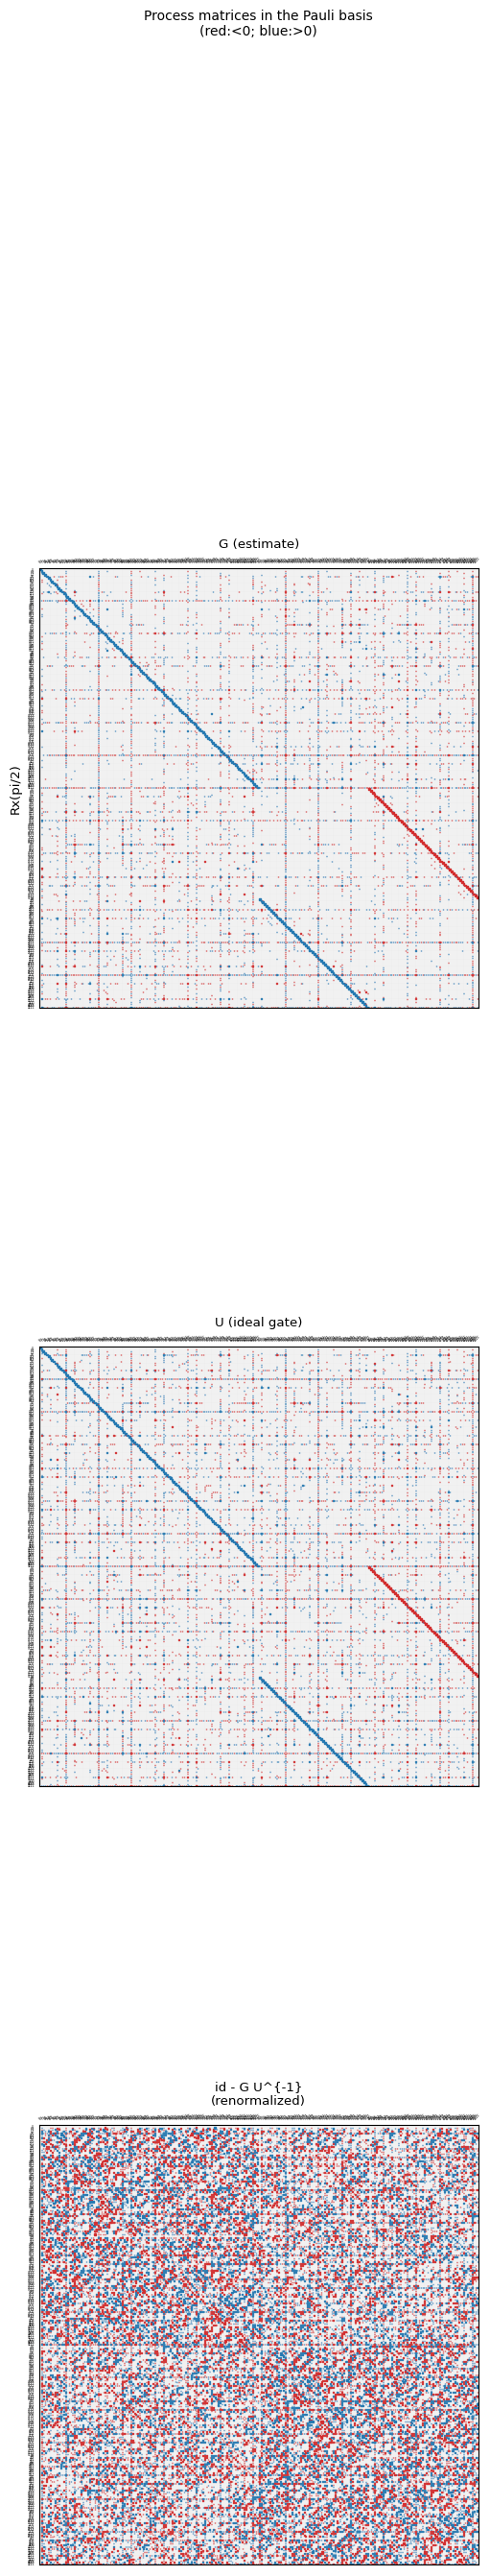

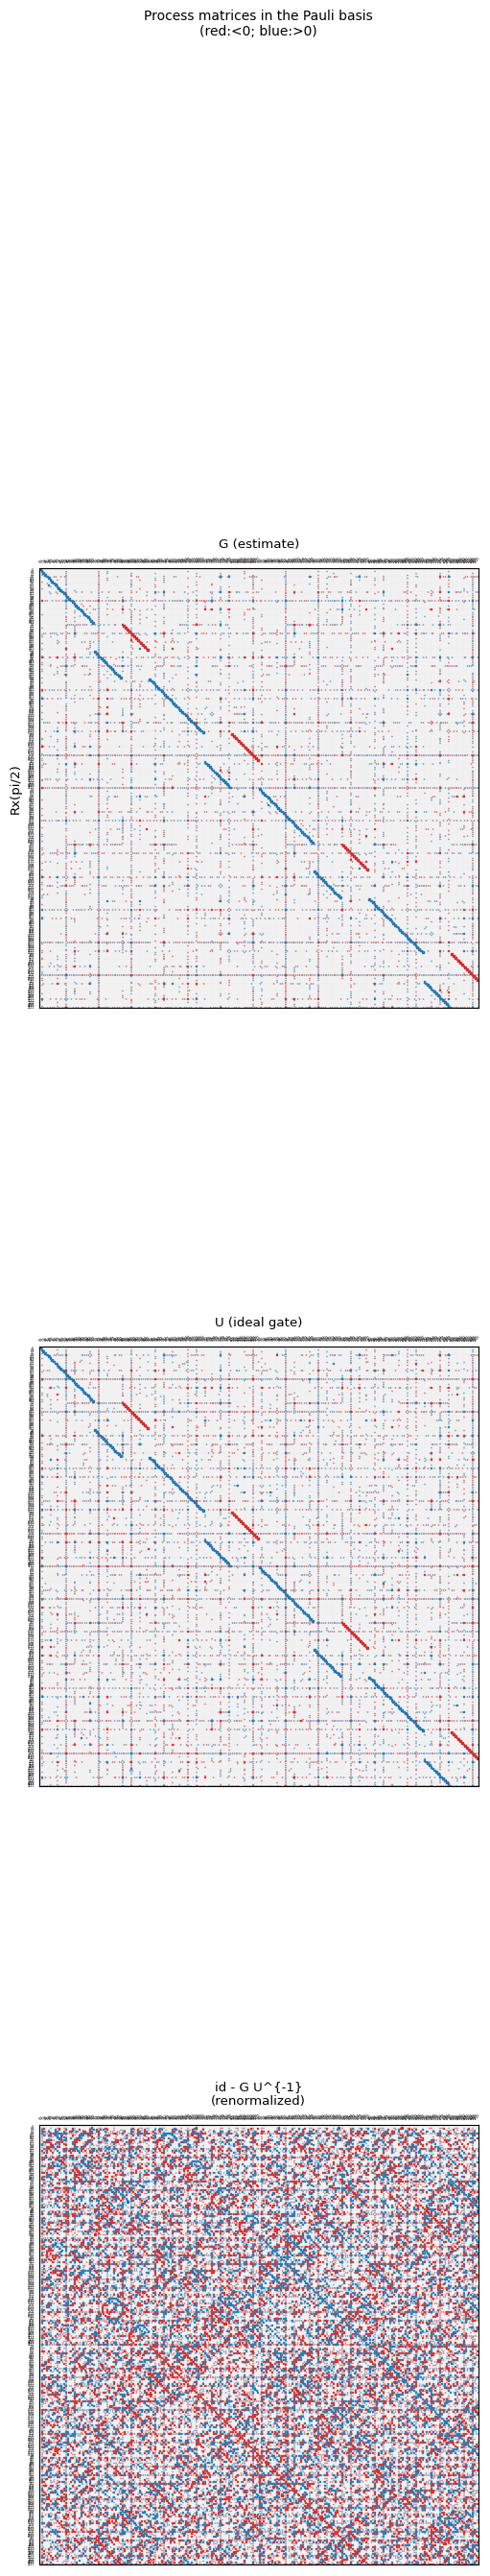

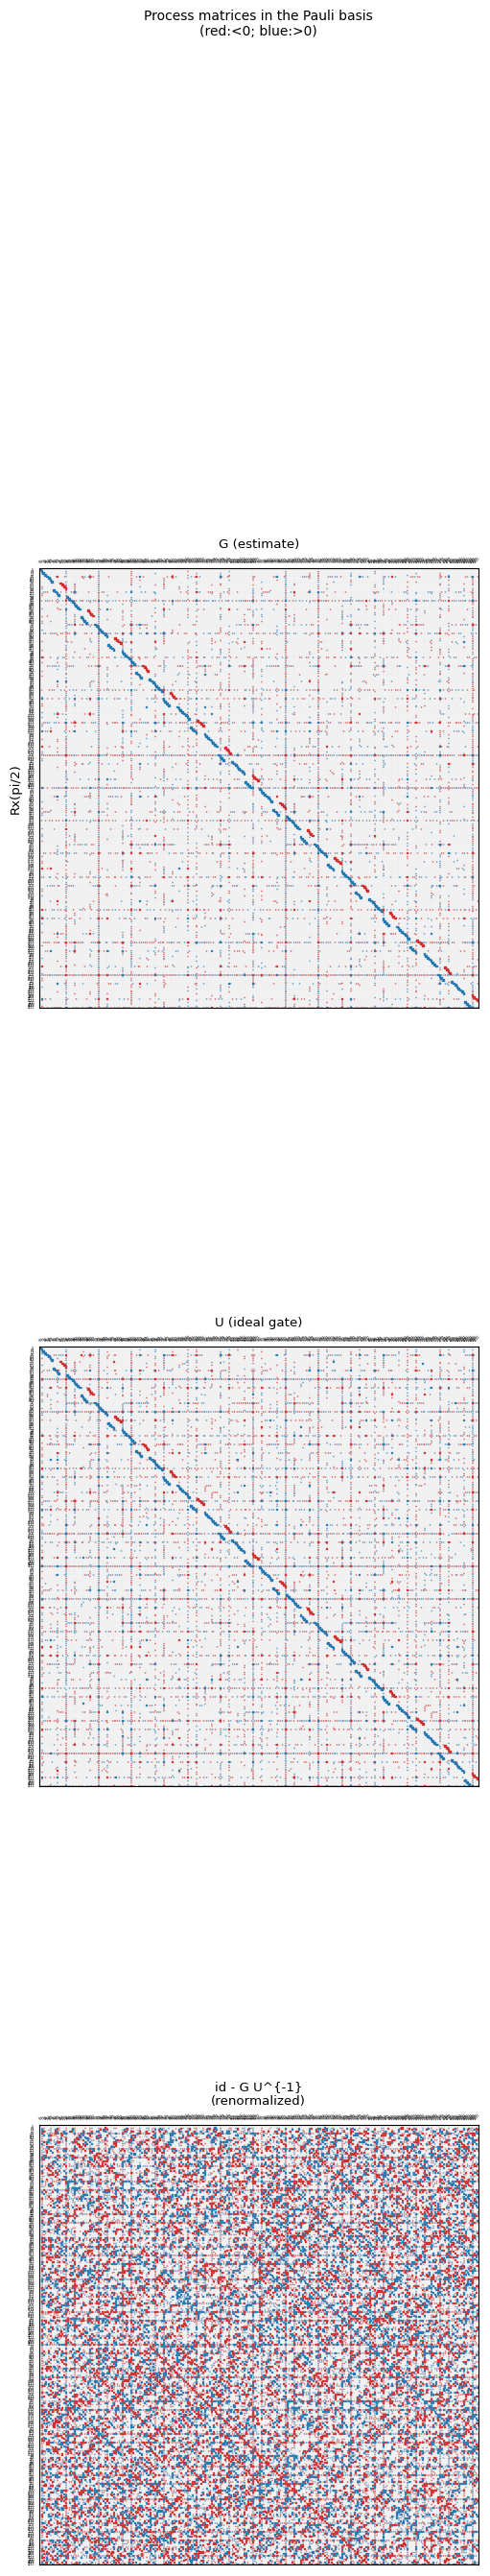

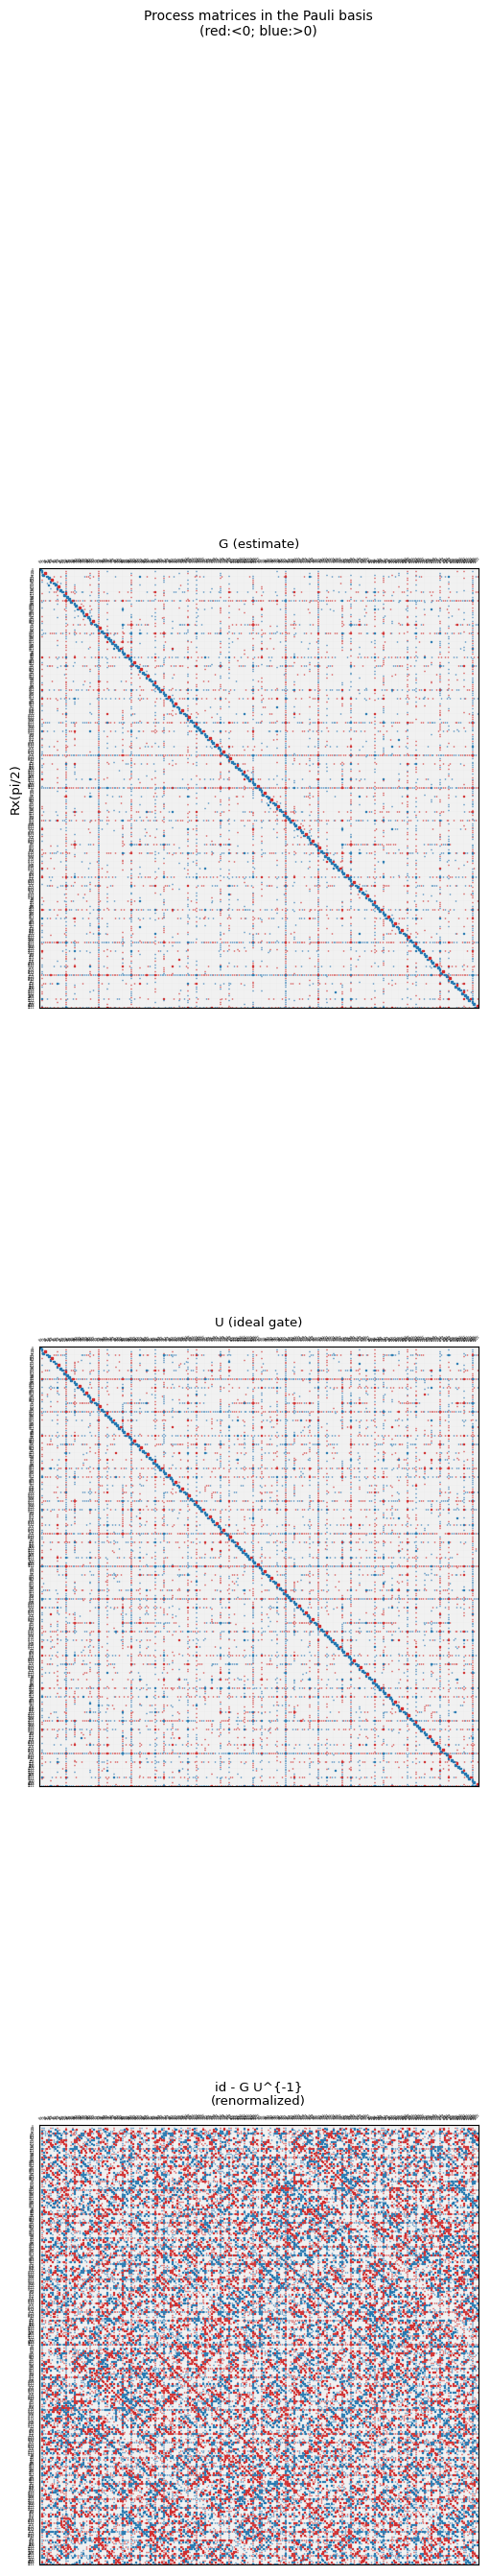

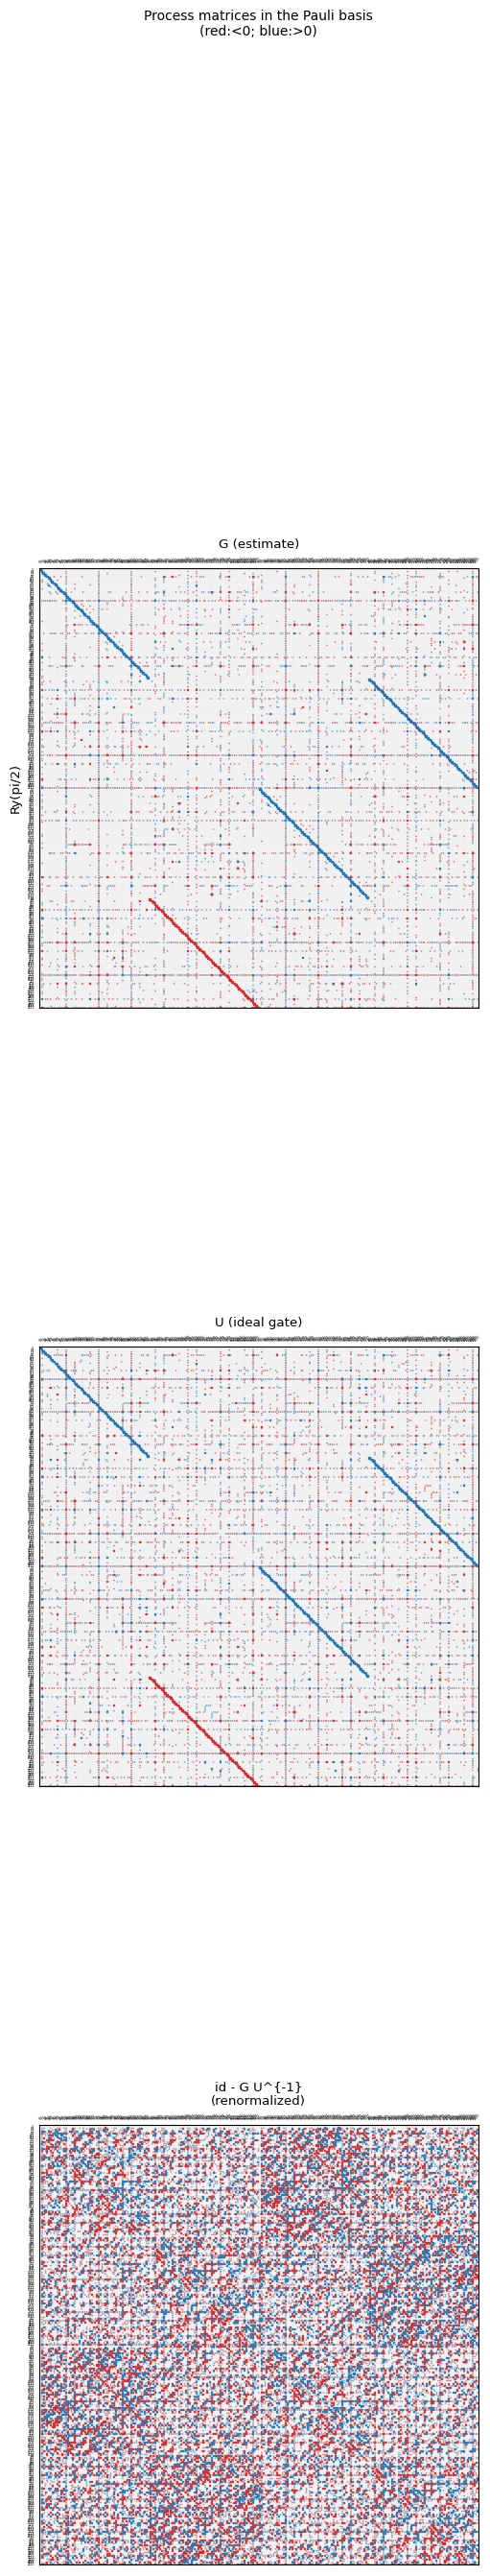

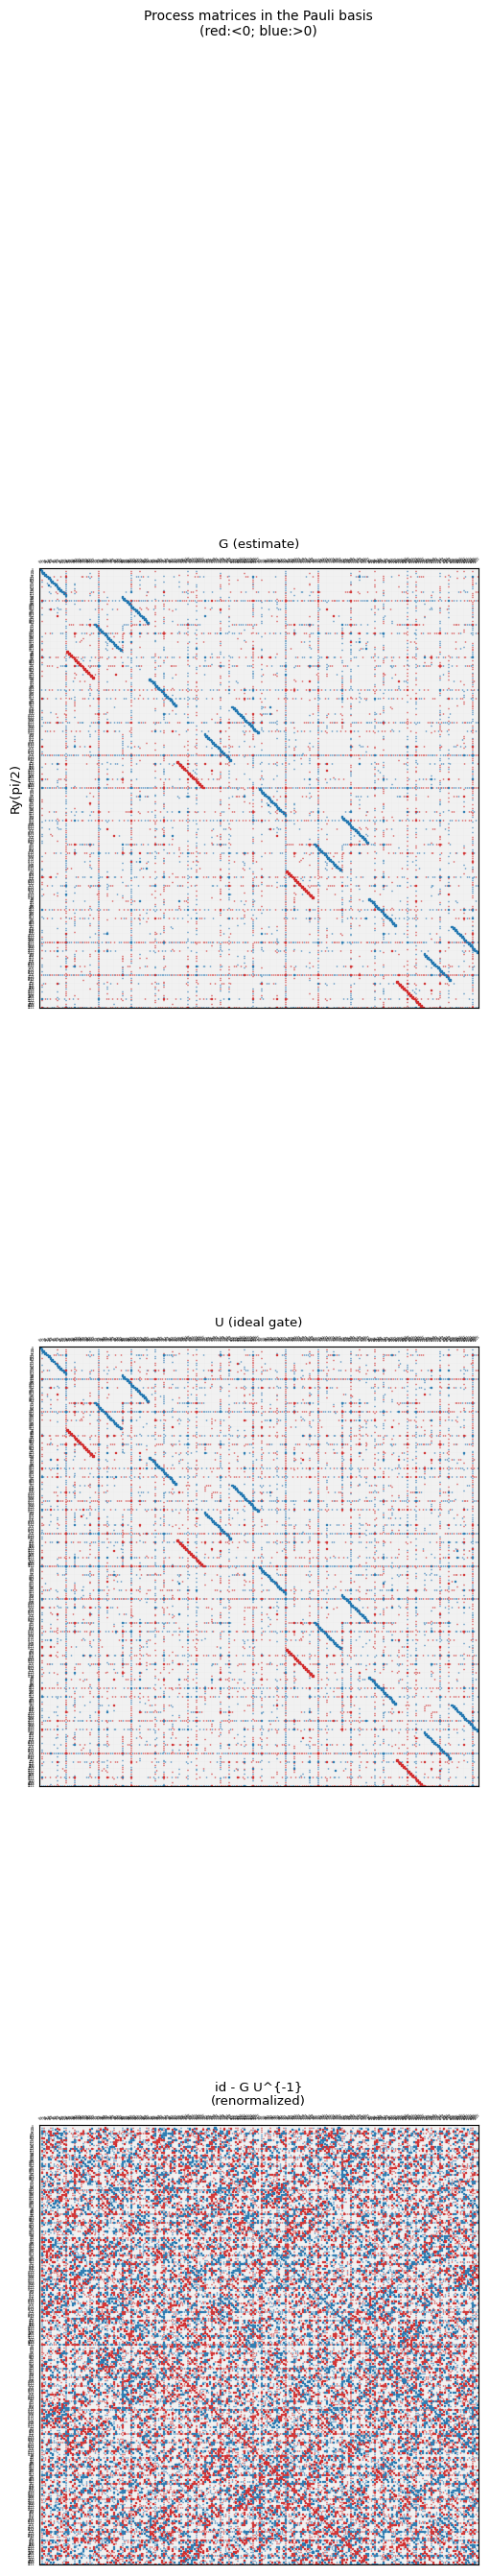

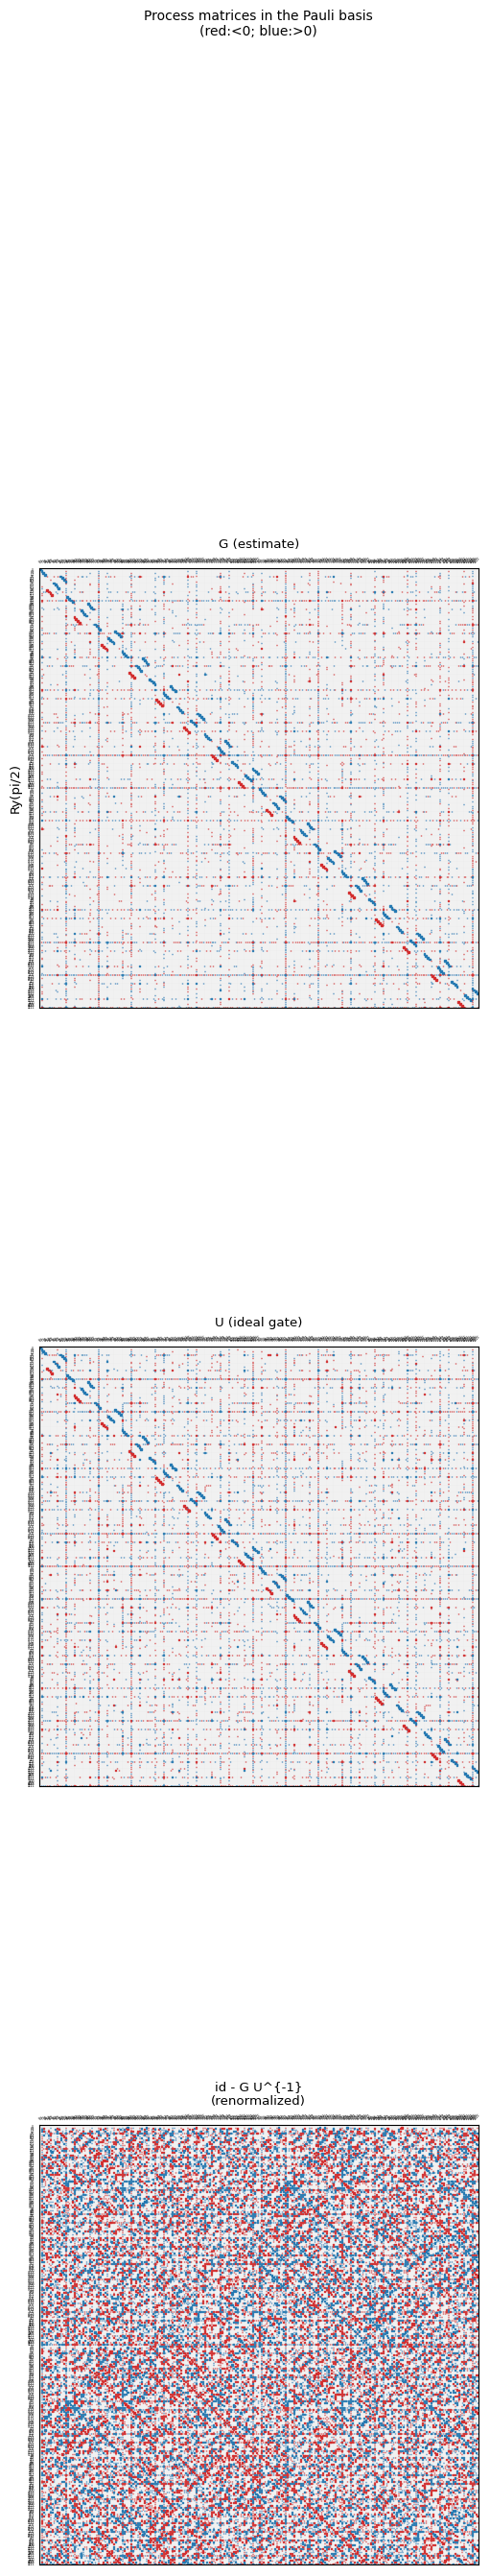

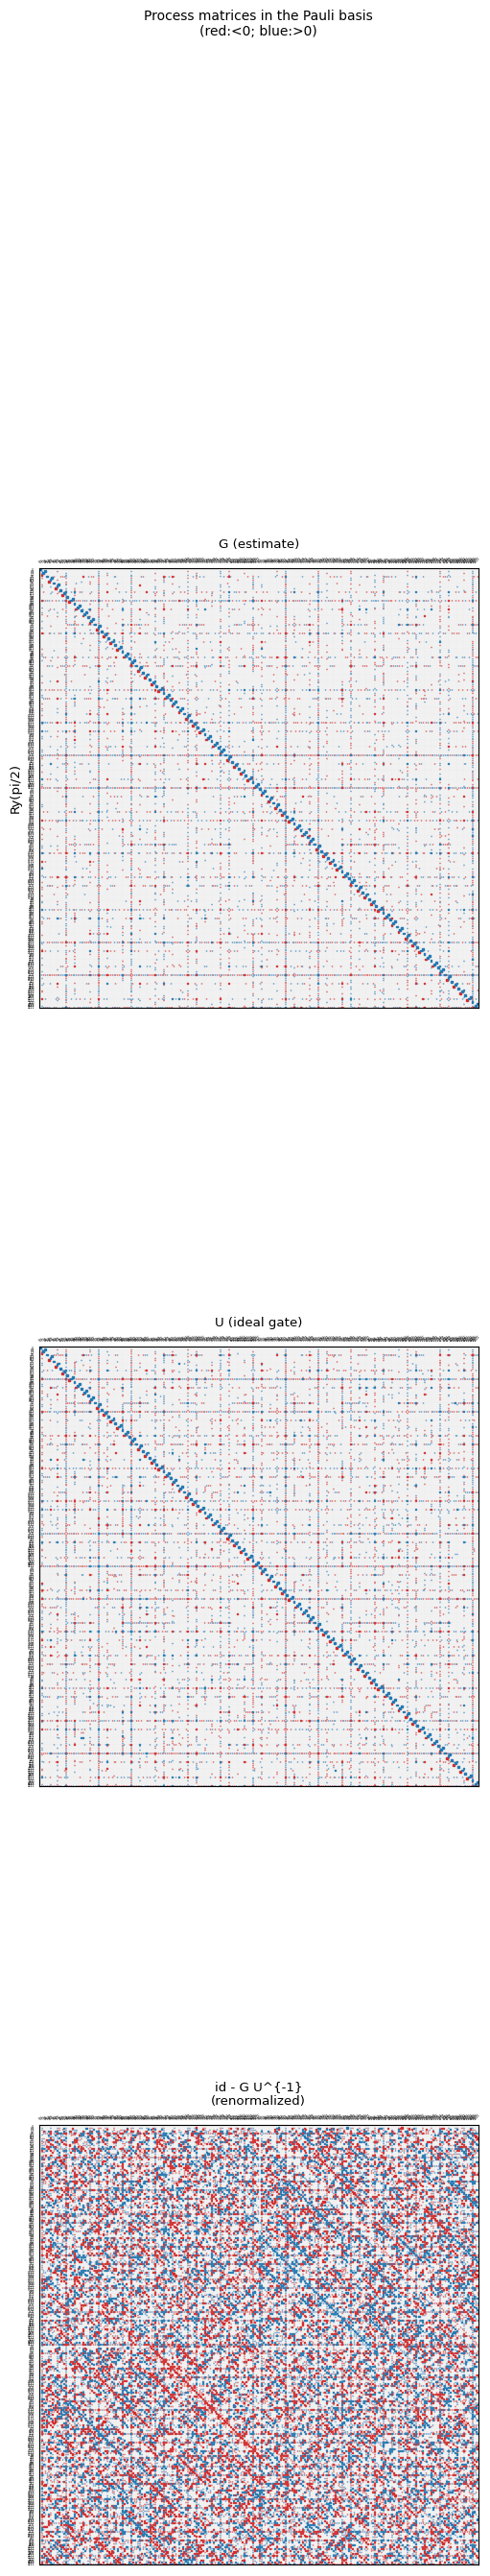

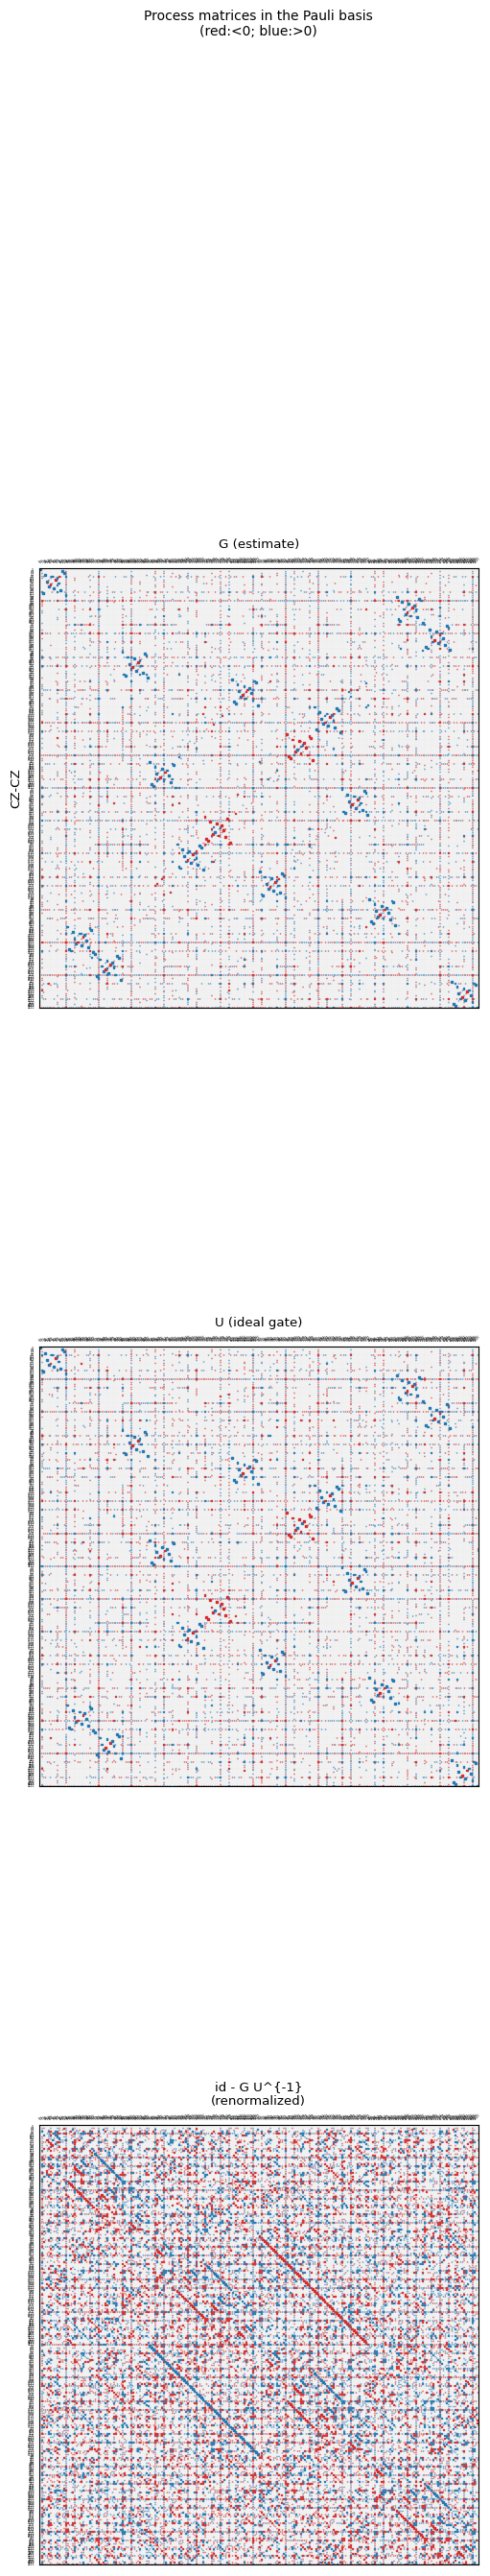

In [28]:
figures = generate_gate_err_pdf(
        "",
        gates1=kraus_guage_opt_pauli,
        gates2=kraus_target_pauli,
        basis_labels=pauli_labels,
        gate_labels=gate_labels,
        return_fig=True,
    )